# Анализ доходности и оценок — Мария

## Бюджет и кассовые сборы

Данные о бюджете и мировых сборах получены в большой степени с сайта https://www.the-numbers.com. Данные в таблице содержатся по 90 строкам, однако если учитывать год выпуска, то 84. Некторые данные не удалось извлечь, так как не у всех фильмов есть "Worldwide Box Office" и/или данных о бюджете (пример: Wiener Dog Internationals). Также был изучен сайт https://www.boxofficemojo.com/title/tt4144190/?ref_=bo_se_r_1$0, на которох также не было данных (пример: фильма с названием "Wiener Dog Internationals" нет, есть только "Wiener Dog").

Дополнительно были изучены датасеты с сайта Kaggle, но данных о бюджете и доходах для слияния было недостаточно (около 50 соединений, последующее слияние датасетов к значительному увелечению данных не приводило). Изучены доступные датасеты от IMDb (IMDb Non-Commercial Datasets https://developer.imdb.com/non-commercial-datasets/$0), в которых также нет данных о финансах.

На форуме Reddit (https://www.reddit.com/r/datasets/comments/gn5hp7/dataset_for_box_office_releases_19702020/$0) удалось найти большой датасет. При его обработке был учен комментарий, что много 0 в колонке бюджет (This isn't accurate. Whole swathes of movies are listed to have budgets of zero and revenue in the ones-place). К итоговому датасету добавилось 16 строк по бюджету.

Скорее всего данные не доступны в связи с коммерческой тайной (оценка гонорара актеров, финансовые возможности компании и т.д.), а имеющиеся информационные источники берут информацию друг у друга.

In [1]:
import pandas as pd
data = pd.read_csv("NetflixShows_clear.csv")
data.head(1)

,index,title,rating,ratingLevel,release year,user rating score,user rating size,sceneDesc,type,audience_segment,mass_appeal,kids_appeal,youth_appeal,adult_appeal,genre,country,imdbRating,imdbVotes,rated
0,0,White Chicks,PG-13,Parents strongly cautioned. May be inappropria...,2004,82.0,80,"crude and sexual humor, language and some drug...",movie,Teens,0.1,0.2,1.0,0.6,NaN,NaN,NaN,NaN,NaN


In [2]:
#датасет, полученный с сайта  https://www.the-numbers.com и https://www.boxofficemojo.com/
df_budget = pd.read_excel("movie_financials_the_numbers_boxofficemojo.xlsx")
df_budget["release year"] = pd.to_datetime(df_budget["Release Date / Year"],errors="coerce").dt.year.astype("Int64")
df_budget = df_budget.drop(columns=["Matched Title", "Release Date / Year", 'Match Status', 'Source'])
df_budget = df_budget.dropna(subset=["release year", 'Worldwide Box Office', 'Production Budget'])
df_budget

,Title,Worldwide Box Office,Production Budget,release year
0,White Chicks,1.114490e+08,20000000.0,2004
1,Lucky Number Slevin,5.549547e+07,27000000.0,2006
29,Scream,1.730467e+08,15000000.0,1996
73,Zootopia,1.019430e+09,150000000.0,2016
74,Meet the Blacks,9.097072e+06,900000.0,2016
...,...,...,...,...
469,Pooh's Heffalump Movie,5.568694e+07,20000000.0,2005
471,Corpse Bride,1.147707e+08,30000000.0,2005
473,Underdogs,1.392649e+06,2500000.0,2013
477,Baby's Day Out,1.658158e+07,50000000.0,1994


In [3]:
pd.set_option("display.float_format", "{:.0f}".format)
#https://sky.pro/wiki/python/formatirovanie-chisel-bez-nauchnoy-notatsii-v-pandas/

In [4]:
#объединение основного датасета и данные по бюджету
df_new = pd.merge(data, df_budget, left_on='title', right_on='Title', how='left')
df_new = df_new.drop(columns='Title')
df_new.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   index                 500 non-null    int64  
 1   title                 500 non-null    object 
 2   rating                500 non-null    str    
 3   ratingLevel           500 non-null    str    
 4   release year_x        500 non-null    int64  
 5   user rating score     256 non-null    float64
 6   user rating size      500 non-null    int64  
 7   sceneDesc             89 non-null     str    
 8   type                  500 non-null    str    
 9   audience_segment      500 non-null    str    
 10  mass_appeal           500 non-null    float64
 11  kids_appeal           500 non-null    float64
 12  youth_appeal          500 non-null    float64
 13  adult_appeal          500 non-null    float64
 14  genre                 0 non-null      float64
 15  country               0 non-null  

84 строки по бюджету соединились с 86 строками из основного датасета, необходимо убрать 2 строки, чтобы при высчитывании корреляции не было ложных данных 

In [5]:
df_new[df_new.duplicated('title', keep=False)].sort_values(by='title')

,index,title,rating,ratingLevel,release year_x,user rating score,user rating size,sceneDesc,type,audience_segment,...,youth_appeal,adult_appeal,genre,country,imdbRating,imdbVotes,rated,Worldwide Box Office,Production Budget,release year_y
128,167,Bordertown,TV-14,Parents strongly cautioned. May be unsuitable ...,2016,86,80,NaN,tv,Teens,...,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>
257,449,Bordertown,TV-MA,For mature audiences. May not be suitable for...,2016,NaN,82,NaN,tv,Adults,...,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>
321,568,Goosebumps,TV-Y7,Suitable for children ages 7 and older,1998,88,80,NaN,tv,Kids,...,0,0,NaN,NaN,NaN,NaN,NaN,158905324,58000000,2015
366,632,Goosebumps,PG,Parental guidance suggested. May not be suitab...,2015,90,80,"scary and intense creature action and images, ...",movie,Family,...,1,0,NaN,NaN,NaN,NaN,NaN,158905324,58000000,2015
119,151,Skins,TV-MA,For mature audiences. May not be suitable for...,2013,NaN,82,NaN,tv,Adults,...,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>
135,181,Skins,TV-MA,For mature audiences. May not be suitable for...,2017,NaN,82,NaN,tv,Adults,...,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>
269,504,Star Wars: The Clone Wars,PG,Parental guidance suggested. May not be suitab...,2008,57,80,"sci-fi action violence throughout, brief langu...",movie,Family,...,1,0,NaN,NaN,NaN,NaN,NaN,68695443,8500000,2008
276,512,Star Wars: The Clone Wars,TV-PG,Parental guidance suggested. May not be suitab...,2014,93,80,NaN,tv,Family,...,1,0,NaN,NaN,NaN,NaN,NaN,68695443,8500000,2008


In [6]:
df_new = df_new.drop(index=[321, 276])
#были оставлены строки с большим кол-вом информации

In [7]:
#добавление второго датасета с сайта Kaggle
df_budget2 = pd.read_csv('movies_metadata.csv')
#df_budget2.columns.tolist()
df_budget2['budget'] = pd.to_numeric(df_budget2['budget'], errors='coerce').astype('float64')
#df_budget2.info()
df_budget2_clean = df_budget2[df_budget2['budget'] != 0] #на редите было сказано, что много 0, поэтому можно сразу отсеять
df_budget2_clean = df_budget2_clean.drop_duplicates(subset=['title', 'release_date'], keep='first')
df_budget2_clean['release year'] = pd.to_datetime(df_budget2_clean['release_date'], errors='coerce').dt.year.astype('Int64')
print(f'Кол-во строк во втором датасете с данными по бюджету:', df_budget2.shape[0],
      "\nКол-во строк во втором датасете с данными по бюджету после очистки от нулевых значений", df_budget2_clean.shape[0])
df_budget2_clean.info()


Кол-во строк во втором датасете с данными по бюджету: 45466 
Кол-во строк во втором датасете с данными по бюджету после очистки от нулевых значений 8883
<class 'pandas.DataFrame'>
Index: 8883 entries, 0 to 45422
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  8883 non-null   str    
 1   belongs_to_collection  1587 non-null   str    
 2   budget                 8880 non-null   float64
 3   genres                 8883 non-null   str    
 4   homepage               2756 non-null   str    
 5   id                     8883 non-null   str    
 6   imdb_id                8881 non-null   str    
 7   original_language      8883 non-null   str    
 8   original_title         8883 non-null   str    
 9   overview               8836 non-null   str    
 10  popularity             8881 non-null   object 
 11  poster_path            8876 non-null   str    
 12  production_companies  

/var/folders/_w/1360zfs92kv0_ffpdtv1d0_m0000gn/T/ipykernel_44023/2315849442.py:2: DtypeWarning: Columns (0: popularity) have mixed types. Specify dtype option on import or set low_memory=False.
  df_budget2 = pd.read_csv('movies_metadata.csv')


In [8]:
#объединение основного датасета (df + df_budget) со второмым c Reddit/Kaggle
df_full = pd.merge(df_new, df_budget2_clean[['original_title', 'budget', 'production_companies', 'production_countries', 'release year', 'runtime', 'revenue']], left_on=['title', 'release year_x'], right_on=['original_title', 'release year'], how='left')
df_full['Production Budget'] = df_full['Production Budget'].fillna(df_full['budget'])
df_full['Worldwide Box Office'] = df_full['Worldwide Box Office'].fillna(df_full['revenue'])
df_full = df_full.drop(columns=['original_title', 'budget'])
df_full.shape

(498, 27)

In [9]:
df_full = df_full.dropna(subset=['Worldwide Box Office', 'Production Budget'])
df_full.info()

<class 'pandas.DataFrame'>
Index: 100 entries, 0 to 490
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   index                 100 non-null    int64  
 1   title                 100 non-null    object 
 2   rating                100 non-null    str    
 3   ratingLevel           100 non-null    str    
 4   release year_x        100 non-null    int64  
 5   user rating score     71 non-null     float64
 6   user rating size      100 non-null    int64  
 7   sceneDesc             61 non-null     str    
 8   type                  100 non-null    str    
 9   audience_segment      100 non-null    str    
 10  mass_appeal           100 non-null    float64
 11  kids_appeal           100 non-null    float64
 12  youth_appeal          100 non-null    float64
 13  adult_appeal          100 non-null    float64
 14  genre                 0 non-null      float64
 15  country               0 non-null      f

In [10]:
df_full = df_full.drop(columns=['index', "release year_y", 'genre', 'rated', 'country', 'imdbRating', 'imdbVotes', 'release year', 'sceneDesc', 'revenue'])

In [11]:
df_full.head()
df_full.shape

(100, 17)

In [12]:

df_full["Production Budget"].min()
#значение неадекватное для бюджета фильма, поэтому лучше удалить строки меньше 100к долларов ()

np.float64(5.0)

In [13]:
df_full = df_full[df_full["Production Budget"] >= 100000]
df_full.shape

(99, 17)

In [14]:
df_full["Worldwide Box Office"].min()

np.float64(0.0)

In [15]:
df_full = df_full[df_full["Worldwide Box Office"] != 0]

In [16]:
df_full["Worldwide Box Office"].min()

np.float64(5940.0)

## Анализ
Задача выявить корреляции связанные с доходностью фильма/шоу

In [17]:
df_full["Production Budget"].describe()

count          92
mean     55387826
std      52588310
min        700000
25%      17250000
50%      39500000
75%      75625000
max     300000000
Name: Production Budget, dtype: float64

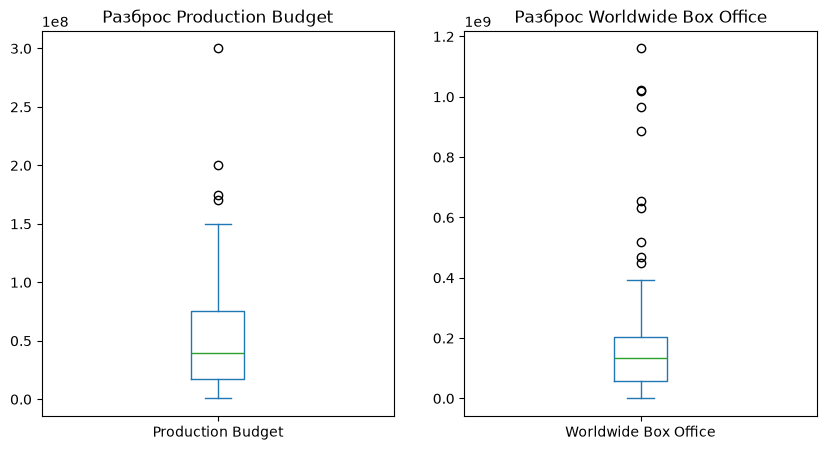

In [18]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
df_full['Production Budget'].plot(kind="box", ax=axes[0])
axes[0].set_title('Разброс Production Budget')
df_full['Worldwide Box Office'].plot(kind="box", ax=axes[1])
axes[1].set_title("Разброс Worldwide Box Office")

#plt.tight_layout()
plt.show()

In [19]:
#удаляем только 2 строку в Production budget и 1 в сборах 
df_full = df_full.drop(index=df_full["Production Budget"].idxmax())
df_full = df_full.drop(index=df_full["Worldwide Box Office"].idxmax())
#https://sky.pro/wiki/python/poisk-strok-s-maksimalnym-znacheniem-v-pandas-data-frame/?ysclid=mqo76pqrpf97126523 

## создание новых признаков:
- доход фильма (Мировой кассовый сбор - бюджет)
- процент дохода (Мировой кассовый сбор/ бюджет*100)


In [20]:
df_full['profit'] = df_full['Worldwide Box Office'] - df_full['Production Budget']

In [21]:
df_full['profit perc'] = round((df_full['profit'] / df_full['Production Budget']) *100, 2)

In [22]:
df_full.head(1)

,title,rating,ratingLevel,release year_x,user rating score,user rating size,type,audience_segment,mass_appeal,kids_appeal,youth_appeal,adult_appeal,Worldwide Box Office,Production Budget,production_companies,production_countries,runtime,profit,profit perc
0,White Chicks,PG-13,Parents strongly cautioned. May be inappropria...,2004,82,80,movie,Teens,0,0,1,1,111448997,20000000,"[{'name': 'Columbia Pictures', 'id': 5}, {'nam...","[{'iso_3166_1': 'US', 'name': 'United States o...",109,91448997,457


In [23]:
import seaborn as sns
#изначальный вариант, однако в колонках runtime и user rating score сильно меньше данных
#pd.set_option('display.float_format', '{:.3f}'.format)
#corr_data = df_full[['release year_x', 'user rating score', 'Worldwide Box Office', 'runtime', 'Production Budget', 'profit', 'profit perc']].dropna()
#sns.heatmap(corr_data.corr(), cmap = 'summer', annot=True) 

#несостоявщиеся выводы: 
#умеренная корреляция между бюджетом и рейтингом - чем дороже картина, тем среднее оценок выше (0,62)
#то есть можно предположить, что большее кол-во вложенных средств способствует более высоской оценке, 
#так как повышается качество контента (звуковое сопровождение, операторская работа, сценаристы, режиссер и т.д.), однако кол-во вложенных средств не гарантирует оккупаемость

#также высокий рейтинг коррелирует умеренно с доходностью фильма (0,48)

#наблюдается положительная корреляция между годом релиза и оценкой пользователей. 
# Так что можно предположить, что с годами производство контента стало больше отвечать запросу зрителя.

#продолжительность картины ни с чем не коррелирует

##если бы был еще использован признак user rating size:
#между размером аудитории и процентом окупаемости существует слабая отрицательная корреляция. 
#Можно предположить, что скорее важна платежеспособность аудитории, чем ее размер. 

(90, 5)

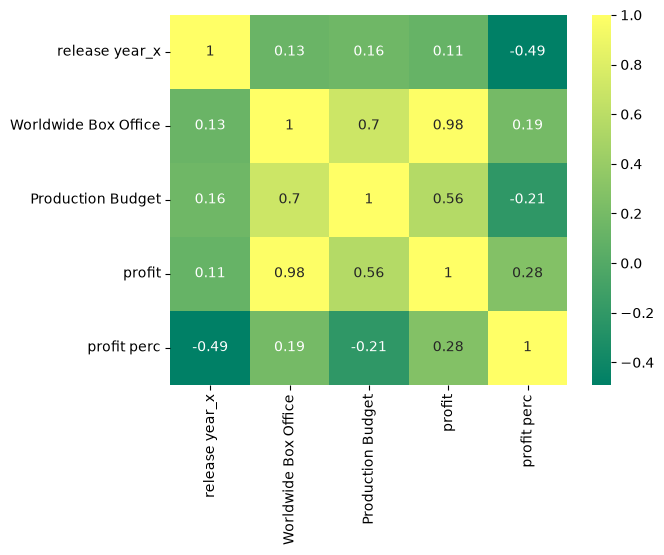

In [28]:
pd.set_option('display.float_format', '{:.3f}'.format)
corr_data = df_full[['release year_x', 'Worldwide Box Office', 'Production Budget', 'profit', 'profit perc']].dropna()
sns.heatmap(corr_data.corr(), cmap = 'summer', annot=True)
corr_data.shape

#### вывод 1: 
есть очень cильная корреляция между доходностью и кассовыми сборами, что может говорить, что рассматриваемые фильмы имеют хорошую окупаемость (0,98), однако в процентном соотношении корреляция слабая (0,19)
#### вывод 2: 
высокая корреляция между бюджетом фильма и сборами, что может означать, что у более дорогих картин - больше сборы (0,7), так же заметная корреляция между бюджетом и суммой дохода (0.56)
#### вывод 3:
год релиза отрицательно коррелирует с процентом прибыли, что может означать, что более новые фильмы - менее окупаемы. Можно предположить, что доходность падает, так как растет переход аудитории в онлайн формат в плане потребления контента. Здесь могут также выступать причинами пиратское потребление контента или формат подписки (покупка пакета услуг, а не каждой отдельной единицы контента) 


In [55]:
#для дальнейшего анализа удаляем выбросы, чтобы посмотреть корректно среднее
Q1 = df_full["Production Budget"].quantile(0.25)
Q3 = df_full["Production Budget"].quantile(0.75)
IQR = Q3 - Q1
lw = Q1 - 1.5 * IQR
up = Q3 + 1.5 * IQR
df_full_clean = df_full[(df_full["Production Budget"] >= lw)&(df_full['Production Budget']<=up)]

In [57]:
df_full_clean["is_success"] = df_full_clean['profit']> 0
df_full_clean.groupby("is_success")[['Production Budget', 'Worldwide Box Office', 'user rating score', 'runtime', 'profit perc']].mean()

,Production Budget,Worldwide Box Office,user rating score,runtime,profit perc
is_success,,,,,
False,39337500.000,26549156.188,78.778,99.375,-39.938
True,49961690.141,188883703.197,82.143,97.982,493.470


#### вывод 4:
средняя оценка незначительно (на 3,4 из 100 баллов) ниже у "провальных" картин, чем у успешных, однако затрат в среднем больше, а сборов меньше 

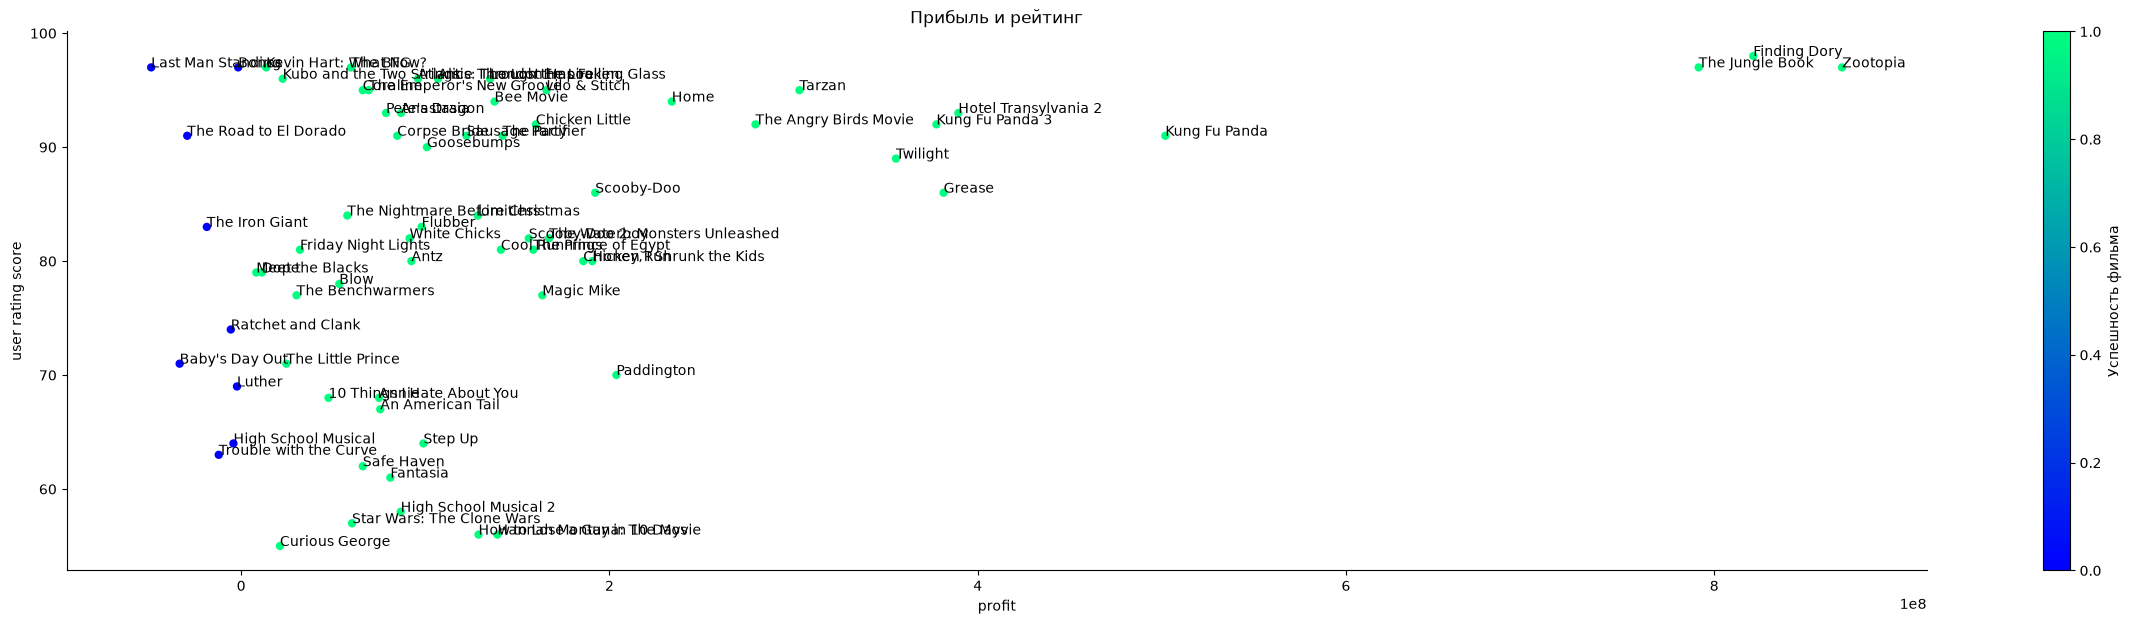

In [112]:
#из материалов по визуализации:B. (Additional 2 - Advanced visualizations)
fig, ax = plt.subplots(figsize=(30, 7))

color_graph = ax.scatter(
    df_full['profit'],
    df_full['user rating score'],
    c=df_full['profit'] > 0,
    cmap='winter',
    alpha=1,
    linewidth=0
)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')

for i in df_full.index:
    ax.text(
        df_full.loc[i, 'profit'],
        df_full.loc[i, 'user rating score'],
        df_full.loc[i, 'title'],
        fontsize=10
    )

ax.set_xlabel('profit')
ax.set_ylabel('user rating score')
ax.set_title("Прибыль и рейтинг")

plt.colorbar(color_graph, label='Успешность фильма')

plt.show()

#### вывод 5: 
наличие прибыли фильма не отражает успешность фильма по рейтингу среди зрителей

#### ОДНАКО: оценивать фильм по сборам в данном формате считаем некорректным,, так как информации о методе подсчета данных нет. Каждый фильм использует свою методику и сценарий (только кассовый сбор в кинотеатрах, проект окупился - прекращение отслеживания/обновления данных, учет доходности со стриминговых платформ и т.д.)

#### ПОЭТОМУ: успешность картины лучше рассчитать по оценкам пользователей, так как они имеют накопительный эффект и регулярно обновляются

(256, 6)

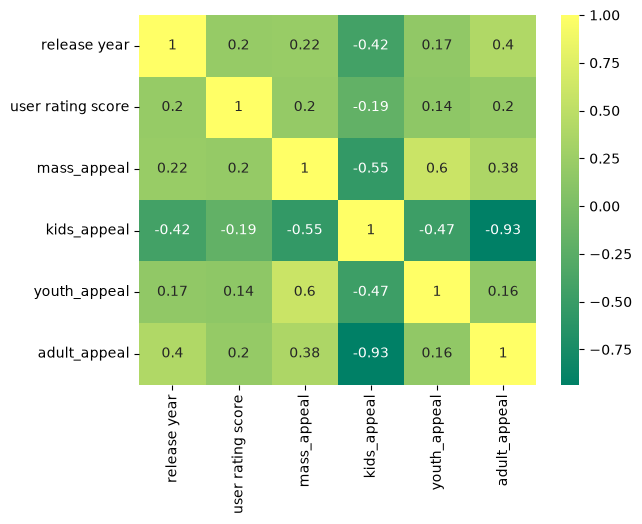

In [118]:
corr_data2 = data[['release year', "user rating score", 'mass_appeal', 'kids_appeal', 'youth_appeal', 'adult_appeal']].dropna()
sns.heatmap(corr_data2.corr(), cmap = 'summer', annot=True)
corr_data2.shape

## Промежуточные выводы

**Промежуточный вывод:**